# Random Forest Training (10-Band + Focal STD + GLCM + Spectral Indices)

This notebook trains **only Random Forest** on paired `*_img.tif` / `*_msk.tif` files.

Feature design (16 total):
- **8 spectral bands**: B2, B3, B4, B7, B8, B8A, B11, B12 — *B5 & B6 (red-edge) dropped as low-PCA-rank redundant*
- **2 focal STD features**: B8-STD, B4-STD (window=5) — *focal means dropped as redundant with raw bands*
- **3 GLCM texture features** from B8: Contrast, Dissimilarity, Energy — *Homogeneity dropped (correlated with Energy)*
- **3 spectral indices**: NDVI, NDBI, MNDWI — *physics-grounded separators for Greenery, Cement, Water*

Normalization: if 99th-percentile > 2.0 → divide by 10000 and clip [0, 1], else clip directly.

In [17]:
import importlib.util
import subprocess
import sys

def ensure_package(pkg_name):
    if importlib.util.find_spec(pkg_name) is None:
        print(f'Installing {pkg_name}...')
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg_name])

ensure_package('scikit-image')
print('Package check complete.')

Installing scikit-image...
Package check complete.


In [ ]:
from pathlib import Path
import random
import warnings

import numpy as np
import rasterio
import matplotlib.pyplot as plt

from skimage.feature import graycomatrix, graycoprops

from sklearn.model_selection import train_test_split
from sklearn.metrics import jaccard_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.ensemble import RandomForestClassifier

warnings.filterwarnings('ignore')

RANDOM_STATE = 42
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

PROJECT_DIR = Path.cwd().resolve()
if PROJECT_DIR.name == 'notebooks':
    PROJECT_DIR = PROJECT_DIR.parent

DATASET_DIR = PROJECT_DIR / 'data' / 'new_dataset'
TARGET_CLASSES = [1, 2, 3, 4]
CLASS_NAMES = {1: 'Greenery', 2: 'Sand', 3: 'Water', 4: 'Cement'}

# 10-band order in image TIFFs: [B2, B3, B4, B5, B6, B7, B8, B8A, B11, B12]
SPECTRAL_10_NAMES = ['B2', 'B3', 'B4', 'B5', 'B6', 'B7', 'B8', 'B8A', 'B11', 'B12']
IDX_B3  = SPECTRAL_10_NAMES.index('B3')
IDX_B4  = SPECTRAL_10_NAMES.index('B4')
IDX_B8  = SPECTRAL_10_NAMES.index('B8')
IDX_B11 = SPECTRAL_10_NAMES.index('B11')

EPS = 1e-6
FOCAL_WINDOW = 5
GLCM_WINDOW  = 7
GLCM_LEVELS  = 16
GLCM_ANGLES  = [0, np.pi / 4, np.pi / 2, 3 * np.pi / 4]
# Homogeneity dropped — highly correlated with Energy
GLCM_PROPS   = ['contrast', 'dissimilarity', 'energy']

image_paths = sorted(DATASET_DIR.glob('*_img.tif'))
mask_paths  = sorted(DATASET_DIR.glob('*_msk.tif'))

def sample_id(p: Path) -> str:
    return p.name.replace('_img.tif', '').replace('_msk.tif', '')

img_lookup = {sample_id(p): p for p in image_paths}
msk_lookup = {sample_id(p): p for p in mask_paths}
paired_ids = sorted(set(img_lookup) & set(msk_lookup))
pairs = [(img_lookup[sid], msk_lookup[sid]) for sid in paired_ids]

print(f'Dataset: {DATASET_DIR}')
print(f'Paired samples: {len(pairs)}')
print(f'Unmatched images: {len(set(img_lookup) - set(msk_lookup))}')
print(f'Unmatched masks:  {len(set(msk_lookup) - set(img_lookup))}')

Dataset: c:\satellite\project\new_dataset
Paired samples: 517
Unmatched images: 1
Unmatched masks:  0


In [19]:
# ── Spectral subset: drop B5 & B6 (low PCA rank, red-edge redundant) ──────────
SPECTRAL_SUBSET_NAMES = ['B2', 'B3', 'B4', 'B7', 'B8', 'B8A', 'B11', 'B12']
SPECTRAL_SUBSET_IDX   = [SPECTRAL_10_NAMES.index(b) for b in SPECTRAL_SUBSET_NAMES]

# ── Helpers ────────────────────────────────────────────────────────────────────
def local_mean_std_2d(band_2d: np.ndarray, window: int = 5):
    pad = window // 2
    padded = np.pad(band_2d, ((pad, pad), (pad, pad)), mode='reflect')
    windows = np.lib.stride_tricks.sliding_window_view(padded, (window, window))
    mean_map = windows.mean(axis=(-1, -2))
    std_map  = windows.std(axis=(-1, -2))
    return mean_map.astype(np.float32), std_map.astype(np.float32)

def normalize_spectral_10(image_cube: np.ndarray) -> np.ndarray:
    spectral_raw = image_cube[:10].astype(np.float32)
    spectral_scale_probe = np.nanpercentile(spectral_raw, 99)
    if spectral_scale_probe > 2.0:
        spectral_norm = np.clip(spectral_raw / 10000.0, 0.0, 1.0)
    else:
        spectral_norm = np.clip(spectral_raw, 0.0, 1.0)
    return spectral_norm

def quantize_for_glcm(band_2d: np.ndarray, levels: int = 16) -> np.ndarray:
    return np.floor(np.clip(band_2d, 0.0, 1.0) * (levels - 1)).astype(np.uint8)

def compute_spectral_indices(spectral_norm: np.ndarray) -> np.ndarray:
    """Return (3, H, W) array: NDVI, NDBI, MNDWI."""
    b3  = spectral_norm[IDX_B3]
    b4  = spectral_norm[IDX_B4]
    b8  = spectral_norm[IDX_B8]
    b11 = spectral_norm[IDX_B11]
    ndvi  = (b8  - b4)  / (b8  + b4  + EPS)
    ndbi  = (b11 - b8)  / (b11 + b8  + EPS)
    mndwi = (b3  - b11) / (b3  + b11 + EPS)
    return np.stack([ndvi, ndbi, mndwi], axis=0).astype(np.float32)

def glcm_features_for_indices(
    b8_quantized: np.ndarray,
    flat_indices: np.ndarray,
    image_shape,
    window: int = 7,
    levels: int = 16,
    props=None
):
    if props is None:
        props = GLCM_PROPS
    h, w = image_shape
    pad    = window // 2
    padded = np.pad(b8_quantized, ((pad, pad), (pad, pad)), mode='reflect')
    rows = flat_indices // w
    cols = flat_indices  % w
    out  = np.zeros((flat_indices.shape[0], len(props)), dtype=np.float32)
    for i, (r, c) in enumerate(zip(rows, cols)):
        patch = padded[r:r + window, c:c + window]
        glcm  = graycomatrix(
            patch, distances=[1], angles=GLCM_ANGLES,
            levels=levels, symmetric=True, normed=True
        )
        for j, p in enumerate(props):
            out[i, j] = np.mean(graycoprops(glcm, p)[0])
    return out

# 16 features total: 8 spectral + 2 focal-STD + 3 GLCM + 3 indices
FEATURE_NAMES = (
    SPECTRAL_SUBSET_NAMES
    + ['FOCAL_STD_B8', 'FOCAL_STD_B4']
    + [f'GLCM_B8_{p.upper()}' for p in GLCM_PROPS]
    + ['NDVI', 'NDBI', 'MNDWI']
)

print(f'Feature count: {len(FEATURE_NAMES)}')
print(FEATURE_NAMES)


Feature count: 16
['B2', 'B3', 'B4', 'B7', 'B8', 'B8A', 'B11', 'B12', 'FOCAL_STD_B8', 'FOCAL_STD_B4', 'GLCM_B8_CONTRAST', 'GLCM_B8_DISSIMILARITY', 'GLCM_B8_ENERGY', 'NDVI', 'NDBI', 'MNDWI']


In [20]:
def collect_stratified_pixels(
    paired_paths,
    target_per_class=300000,
    per_patch_cap=30000,
    seed=RANDOM_STATE
):
    rng = np.random.default_rng(seed)

    X_chunks = []
    y_chunks = []
    collected = {c: 0 for c in TARGET_CLASSES}

    order = np.arange(len(paired_paths))
    rng.shuffle(order)

    for idx in order:
        img_path, msk_path = paired_paths[idx]

        with rasterio.open(img_path) as src:
            image_cube = src.read().astype(np.float32)

        if image_cube.shape[0] < 10:
            raise ValueError(f'{img_path.name} has {image_cube.shape[0]} bands, expected at least 10.')

        with rasterio.open(msk_path) as src:
            mask = src.read(1).astype(np.int32)

        spectral_norm = normalize_spectral_10(image_cube)

        # --- spectral subset (drop B5, B6) ---
        spectral_subset = spectral_norm[SPECTRAL_SUBSET_IDX]              # (8, H, W)
        spectral_flat   = np.moveaxis(spectral_subset, 0, -1).reshape(-1, len(SPECTRAL_SUBSET_IDX))

        # --- focal STD only (means dropped as redundant) ---
        b8 = spectral_norm[IDX_B8]
        b4 = spectral_norm[IDX_B4]
        _, b8_std = local_mean_std_2d(b8, window=FOCAL_WINDOW)
        _, b4_std = local_mean_std_2d(b4, window=FOCAL_WINDOW)
        focal_maps = np.stack([b8_std, b4_std], axis=0)                   # (2, H, W)
        focal_flat = np.moveaxis(focal_maps, 0, -1).reshape(-1, 2)

        # --- GLCM on B8 ---
        b8_quantized = quantize_for_glcm(b8, levels=GLCM_LEVELS)

        # --- spectral indices ---
        index_maps = compute_spectral_indices(spectral_norm)               # (3, H, W)
        index_flat = np.moveaxis(index_maps, 0, -1).reshape(-1, 3)

        mask_flat = mask.reshape(-1)

        for cls in TARGET_CLASSES:
            remaining = target_per_class - collected[cls]
            if remaining <= 0:
                continue

            cls_idx = np.where(mask_flat == cls)[0]
            if cls_idx.size == 0:
                continue

            take   = min(remaining, per_patch_cap, cls_idx.size)
            chosen = rng.choice(cls_idx, size=take, replace=False)

            glcm_chunk = glcm_features_for_indices(
                b8_quantized=b8_quantized,
                flat_indices=chosen,
                image_shape=mask.shape,
                window=GLCM_WINDOW,
                levels=GLCM_LEVELS,
                props=GLCM_PROPS
            )

            x_chunk = np.concatenate([
                spectral_flat[chosen],   # 8
                focal_flat[chosen],      # 2
                glcm_chunk,              # 3
                index_flat[chosen]       # 3
            ], axis=1).astype(np.float32)

            X_chunks.append(x_chunk)
            y_chunks.append(np.full(take, cls, dtype=np.int32))
            collected[cls] += int(take)

        if all(collected[c] >= target_per_class for c in TARGET_CLASSES):
            break

    if not X_chunks:
        raise RuntimeError('No samples collected. Check dataset paths/masks/classes.')

    X = np.vstack(X_chunks).astype(np.float32)
    y = np.concatenate(y_chunks).astype(np.int32)

    print('Collected per class:')
    for cls in TARGET_CLASSES:
        print(f'  {cls} ({CLASS_NAMES[cls]}): {collected[cls]:,}')
    if not all(collected[c] >= target_per_class for c in TARGET_CLASSES):
        print('Warning: at least one class did not reach target_per_class. Continuing with available pixels.')
    print(f'Total sampled pixels: {len(y):,}')

    return X, y

X, y = collect_stratified_pixels(
    pairs,
    target_per_class=300000,
    per_patch_cap=35000
)

X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
)

print(f'X_train: {X_train.shape} | X_val: {X_val.shape}')


Collected per class:
  1 (Greenery): 300,000
  2 (Sand): 300,000
  3 (Water): 300,000
  4 (Cement): 300,000
Total sampled pixels: 1,200,000
X_train: (960000, 16) | X_val: (240000, 16)


## PCA – Feature Exploration

Standardise all features, run PCA, then inspect:
- **Explained variance** per component (scree plot)
- **Feature loadings** heatmap – which features drive each PC
- **Ranked feature importance** by max absolute loading across the top PCs
- **PC1 vs PC2 scatter** coloured by class to check separability

Feature ranking (most influential → least influential):
   1. FOCAL_STD_B4                    max|loading|=0.771
   2. GLCM_B8_ENERGY                  max|loading|=0.704
   3. FOCAL_STD_B8                    max|loading|=0.704
   4. B2                              max|loading|=0.651
   5. MNDWI                           max|loading|=0.638
   6. NDBI                            max|loading|=0.572
   7. GLCM_B8_CONTRAST                max|loading|=0.534
   8. NDVI                            max|loading|=0.432
   9. GLCM_B8_DISSIMILARITY           max|loading|=0.389
  10. B11                             max|loading|=0.346
  11. B7                              max|loading|=0.340
  12. B8A                             max|loading|=0.338
  13. B8                              max|loading|=0.338
  14. B12                             max|loading|=0.333
  15. B3                              max|loading|=0.332
  16. B4                              max|loading|=0.322


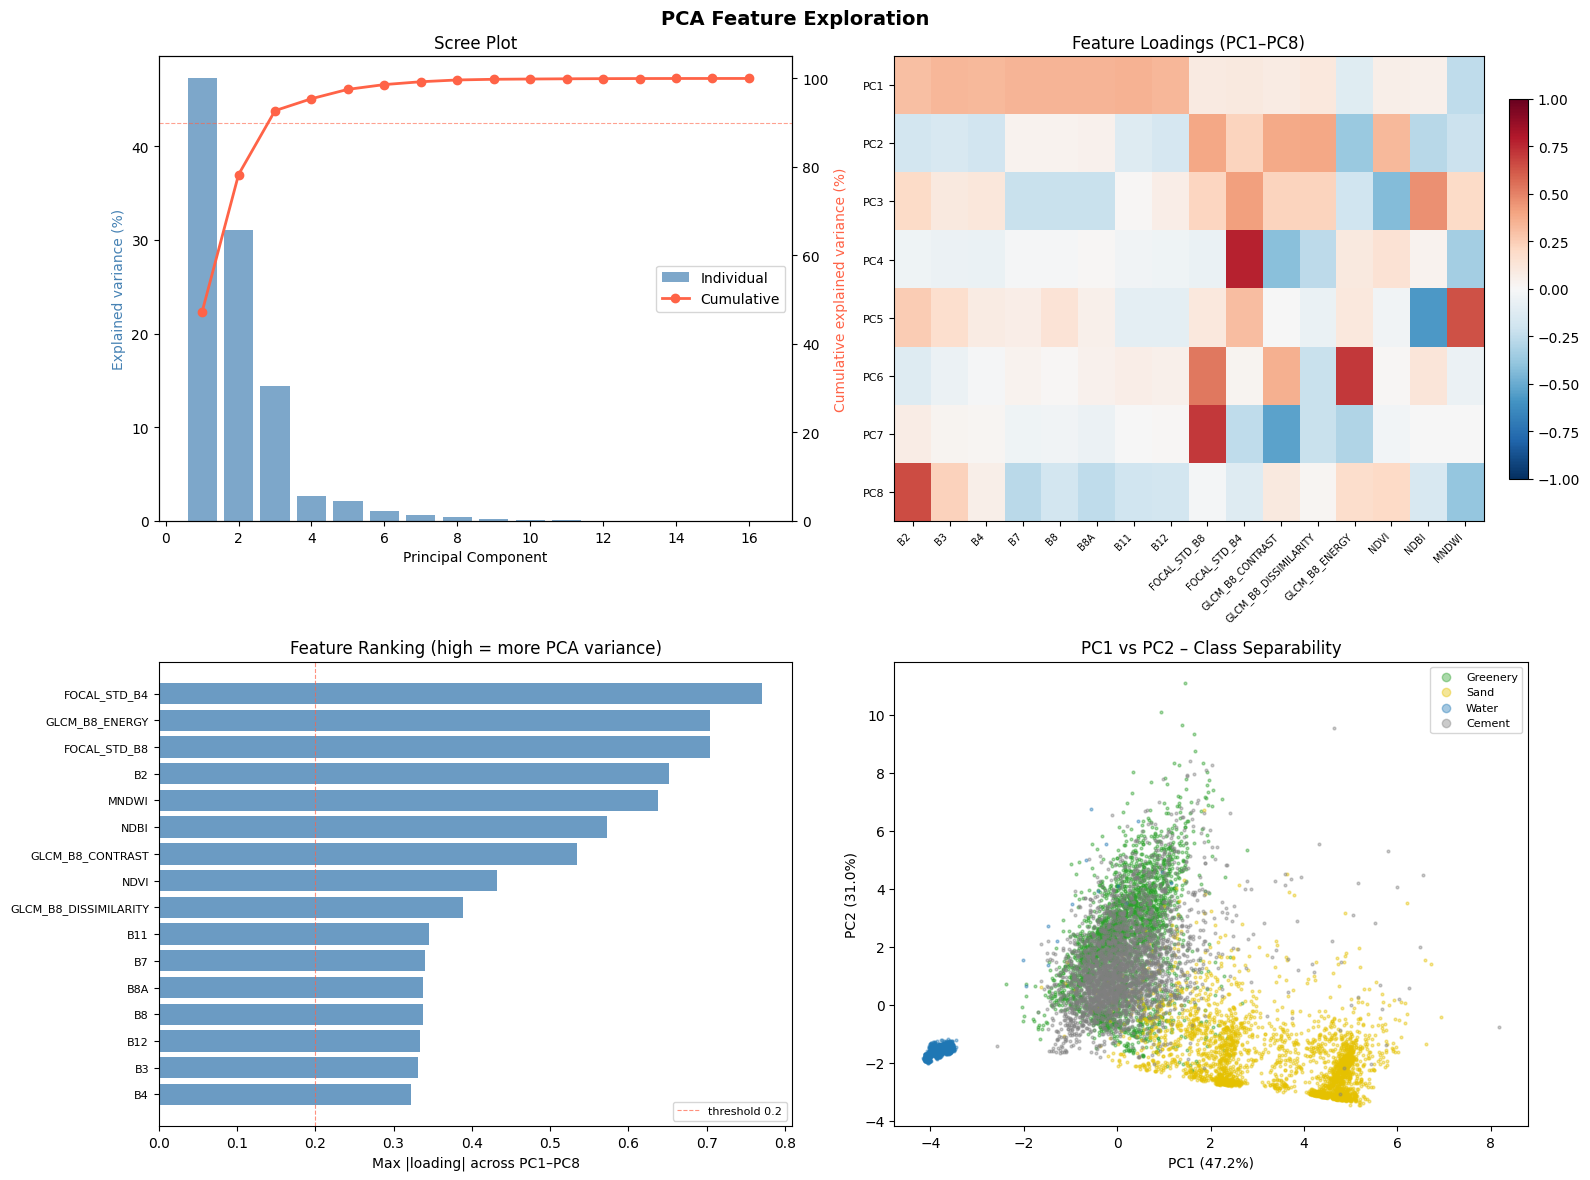

In [22]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# ── Standardise ────────────────────────────────────────────────────────────────
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_train)

# ── Fit full PCA ───────────────────────────────────────────────────────────────
pca_full = PCA(random_state=RANDOM_STATE)
pca_full.fit(X_scaled)

n_features = len(FEATURE_NAMES)
cumvar = np.cumsum(pca_full.explained_variance_ratio_)

# ── Plot layout ────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle("PCA Feature Exploration", fontsize=14, fontweight="bold")

# --- 1. Scree / Cumulative Explained Variance ---
ax = axes[0, 0]
bars = ax.bar(range(1, n_features + 1), pca_full.explained_variance_ratio_ * 100,
              color="steelblue", alpha=0.7, label="Individual")
ax2 = ax.twinx()
ax2.plot(range(1, n_features + 1), cumvar * 100, "o-", color="tomato",
         linewidth=2, label="Cumulative")
ax2.axhline(90, color="tomato", linestyle="--", linewidth=0.8, alpha=0.6)
ax2.set_ylim(0, 105)
ax2.set_ylabel("Cumulative explained variance (%)", color="tomato")
ax.set_xlabel("Principal Component")
ax.set_ylabel("Explained variance (%)", color="steelblue")
ax.set_title("Scree Plot")
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, loc="center right")

# --- 2. Feature Loadings Heatmap (top 8 PCs) ---
N_PC = min(8, n_features)
loadings = pca_full.components_[:N_PC]          # shape (N_PC, n_features)
ax = axes[0, 1]
im = ax.imshow(loadings, aspect="auto", cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(n_features))
ax.set_xticklabels(FEATURE_NAMES, rotation=45, ha="right", fontsize=7)
ax.set_yticks(range(N_PC))
ax.set_yticklabels([f"PC{i+1}" for i in range(N_PC)], fontsize=8)
ax.set_title(f"Feature Loadings (PC1–PC{N_PC})")
plt.colorbar(im, ax=ax, fraction=0.03, pad=0.04)

# --- 3. Feature Importance by Max |Loading| across top PCs ---
max_abs_loading = np.max(np.abs(loadings), axis=0)   # shape (n_features,)
order = np.argsort(max_abs_loading)[::-1]
ax = axes[1, 0]
bars = ax.barh(range(n_features), max_abs_loading[order],
               color="steelblue", alpha=0.8)
ax.set_yticks(range(n_features))
ax.set_yticklabels([FEATURE_NAMES[i] for i in order], fontsize=8)
ax.invert_yaxis()
ax.set_xlabel(f"Max |loading| across PC1–PC{N_PC}")
ax.set_title("Feature Ranking (high = more PCA variance)")
ax.axvline(0.2, color="tomato", linestyle="--", linewidth=0.8, alpha=0.7,
           label="threshold 0.2")
ax.legend(fontsize=8)

print("Feature ranking (most influential → least influential):")
for rank, fi in enumerate(order, 1):
    marker = "  ← low influence" if max_abs_loading[fi] < 0.2 else ""
    print(f"  {rank:2d}. {FEATURE_NAMES[fi]:<30s}  max|loading|={max_abs_loading[fi]:.3f}{marker}")

# --- 4. PC1 vs PC2 scatter coloured by class ---
pca2 = PCA(n_components=2, random_state=RANDOM_STATE)
X_2d = pca2.fit_transform(X_scaled)

ax = axes[1, 1]
palette = {0: "#888888", 1: "#2ca02c", 2: "#e5c100", 3: "#1f77b4", 4: "#7f7f7f"}
for cls_id, cls_name in CLASS_NAMES.items():
    mask_cls = y_train == cls_id
    if mask_cls.sum() == 0:
        continue
    # subsample for speed
    idx = np.where(mask_cls)[0]
    if len(idx) > 3000:
        idx = np.random.default_rng(RANDOM_STATE).choice(idx, 3000, replace=False)
    ax.scatter(X_2d[idx, 0], X_2d[idx, 1],
               s=4, alpha=0.4, label=cls_name,
               color=palette.get(cls_id, None))
ax.set_xlabel(f"PC1 ({pca2.explained_variance_ratio_[0]*100:.1f}%)")
ax.set_ylabel(f"PC2 ({pca2.explained_variance_ratio_[1]*100:.1f}%)")
ax.set_title("PC1 vs PC2 – Class Separability")
ax.legend(markerscale=3, fontsize=8)

plt.tight_layout()
plt.show()


In [ ]:
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=15,
    min_samples_split=10,
    min_samples_leaf=5,
    max_features=0.5,
    max_samples=0.7,
    bootstrap=True,
    n_jobs=-1,
    random_state=RANDOM_STATE
)

rf.fit(X_train, y_train)
y_pred = rf.predict(X_val)

iou_per_class = jaccard_score(
    y_val,
    y_pred,
    labels=TARGET_CLASSES,
    average=None,
    zero_division=0
)

val_miou = jaccard_score(
    y_val,
    y_pred,
    labels=TARGET_CLASSES,
    average='macro',
    zero_division=0
)

iou_by_class = {
    CLASS_NAMES[c]: float(iou_per_class[i])
    for i, c in enumerate(TARGET_CLASSES)
}

print('Validation IoU per class:')
for cls_name, cls_iou in iou_by_class.items():
    print(f'  {cls_name}: {cls_iou:.4f}')

print(f'Validation mIoU: {val_miou:.4f}')
print('Validation classification report:')
print(classification_report(y_val, y_pred, labels=TARGET_CLASSES, target_names=[CLASS_NAMES[c] for c in TARGET_CLASSES]))

Validation IoU per class:
  Unknown: 0.7474
  Greenery: 0.8738
  Sand: 0.9834
  Water: 0.9975
  Cement: 0.8590
Validation mIoU: 0.8922
Validation classification report:
              precision    recall  f1-score   support

     Unknown       0.78      0.95      0.86      9494
    Greenery       0.93      0.93      0.93     60000
        Sand       1.00      0.99      0.99     60000
       Water       1.00      1.00      1.00     60000
      Cement       0.93      0.91      0.92     60000

    accuracy                           0.96    249494
   macro avg       0.93      0.96      0.94    249494
weighted avg       0.96      0.96      0.96    249494



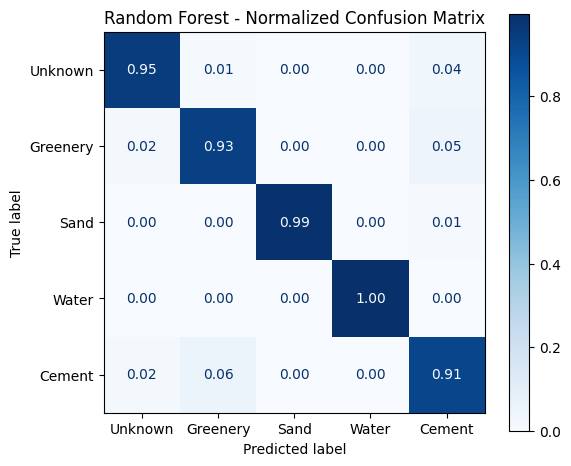

In [ ]:
cm = confusion_matrix(y_val, y_pred, labels=TARGET_CLASSES, normalize='true')
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[CLASS_NAMES[c] for c in TARGET_CLASSES])
fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, cmap='Blues', values_format='.2f', colorbar=True)
plt.title('Random Forest - Normalized Confusion Matrix')
plt.tight_layout()
plt.show()

In [ ]:
import pickle

out_path = DATASET_DIR.parent / 'best_random_forest_10b_glcm.pkl'
payload = {
    'model': rf,
    'model_type': 'random_forest',
    'feature_names': FEATURE_NAMES,
    'class_names': CLASS_NAMES,
    'validation_iou_per_class': iou_by_class,
    'validation_miou': val_miou,
    'config': {
        'focal_window': FOCAL_WINDOW,
        'glcm_window': GLCM_WINDOW,
        'glcm_levels': GLCM_LEVELS,
        'glcm_props': GLCM_PROPS
    }
}

with open(out_path, 'wb') as f:
    pickle.dump(payload, f)

print(f'Saved: {out_path}')

Saved: c:\satellite\project\best_random_forest_10b_glcm.pkl
